# Hidden-State Probe Report Lab
### A progressively deeper analysis of layer-wise emotion recoverability

This notebook is designed to sit **after** the probing pipeline. It does not retrain the probes and it does not alter the frozen hidden states. Its job is to turn the probe outputs into an interpretable research result.

The notebook deliberately gets deeper as you scroll:

**Run audit → result schema → data quality → basic trajectories → probe-vs-shuffle controls → layer geometry → class-level behavior → cross-model comparisons → synthesis.**

> **Core scientific question**
>
> *How recoverable is the target from each frozen hidden-state layer?*

The supplied run already contains an important warning: several ISEAR entries failed before probing because the dataset labels were integer-coded while the analysis contract expected emotion names. That is a **data-contract failure**, not evidence that the model cannot represent ISEAR emotion.

## 0 · What the supplied run actually tells us

From the supplied execution log:

- The successful OPT/goEmo probe had hidden-state shape **(54263, 13, 768)**.
- It was treated as a **multi_label** task with **28 classes** and **13 selected layers**.
- The text alignment was reported as **text=verified | labels=unverified**.
- The probe experiment used **1 repeat** and at most **500 samples**.
- All 28 labels had positive support, but some classes were much rarer than others.
- ISEAR failed immediately for several models with the error:
  **`ISEAR row 0 has unknown emotion '1'; expected ['joy', 'fear', 'anger', 'sadness', 'disgust', 'shame', 'guilt']`**

The analysis below therefore separates three ideas that should never be conflated:

1. **Representation recoverability** — what the probe metrics say.
2. **Measurement validity** — whether the labels, rows, and hidden states were correctly aligned.
3. **Scientific strength** — whether the result is stable enough to support a claim.

## 1 · Analysis contract

### What this notebook is allowed to do

It reads existing probe-result CSV files and optional run manifests / metrics files, then computes secondary summaries and visualisations.

### What it must not do

It must not quietly change the original experiment. In particular, it should not search over probe hyperparameters, choose a nicer metric after seeing the answer, or discard inconvenient layers/models.

The strongest interpretation of a layer-wise curve is therefore:

> **Higher held-out performance means the target is more recoverable from that frozen representation under the chosen probe family and experimental protocol.**

That is evidence about **information recoverability**, not a direct proof of where the model "learned" the emotion.

In [1]:
# ============================================================
# 2. Environment and configuration
# ============================================================
from pathlib import Path
import json, re, warnings, math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

sns.set_theme(context="notebook", style="whitegrid", font_scale=1.0)

# Point this at the matrix output produced by run_matrix().
# Change only this path when moving the notebook to another machine.
PROJECT_ROOT = Path(".")   # e.g. Path("/Volumes/Amirali/hidden_states/experiments/...")
RESULT_ROOT = Path("/Volumes/Amirali/hidden_states")
# Common filenames produced by the probing pipeline.
CSV_GLOBS = [
    "**/*layer_probe_results.csv",
    "**/probe_matrix_checkpoint/per_entry_results/*.csv",
]

# Optional: a directory containing individual run manifests / metrics.json files.
MANIFEST_GLOB = "**/complete_run_metadata.json"
METRICS_GLOB = "**/metrics.json"

print("RESULT_ROOT =", RESULT_ROOT.resolve())

RESULT_ROOT = /Volumes/Amirali/hidden_states


In [2]:
# ============================================================
# 3. Load every available probe-result table
# ============================================================
def find_result_csvs(root: Path):
    paths = []
    for pat in CSV_GLOBS:
        paths.extend(root.glob(pat))
    return sorted(set(p for p in paths if p.is_file()))

csv_paths = find_result_csvs(RESULT_ROOT)

if csv_paths:
    print(f"Found {len(csv_paths)} result CSV(s).")
    for p in csv_paths[:20]:
        print(" •", p)
else:
    print("No result CSVs found yet.")
    print("Set RESULT_ROOT to the matrix/experiment directory, then rerun this cell.")

frames = []
for p in csv_paths:
    try:
        df = pd.read_csv(p)
        df["_source_csv"] = str(p)
        frames.append(df)
    except Exception as exc:
        warnings.warn(f"Could not read {p}: {exc}")

results = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("Combined shape:", results.shape)
display(results.head(10) if not results.empty else pd.DataFrame())

Found 24 result CSV(s).
 • /Volumes/Amirali/hidden_states/experiments/baseline_v5_001/matrix_checkpoint/per_entry_results/._google_electra-small-discriminator_ISEAR_layer_probe_results.csv
 • /Volumes/Amirali/hidden_states/experiments/baseline_v5_001/matrix_checkpoint/per_entry_results/EleutherAI_gpt-neo-125m_goEmo_layer_probe_results.csv
 • /Volumes/Amirali/hidden_states/experiments/baseline_v5_001/matrix_checkpoint/per_entry_results/FacebookAI_roberta-base_ISEAR_layer_probe_results.csv
 • /Volumes/Amirali/hidden_states/experiments/baseline_v5_001/matrix_checkpoint/per_entry_results/FacebookAI_roberta-base_goEmo_layer_probe_results.csv
 • /Volumes/Amirali/hidden_states/experiments/baseline_v5_001/matrix_checkpoint/per_entry_results/distilbert_distilbert-base-uncased_ISEAR_layer_probe_results.csv
 • /Volumes/Amirali/hidden_states/experiments/baseline_v5_001/matrix_checkpoint/per_entry_results/distilbert_distilbert-base-uncased_goEmo_layer_probe_results.csv
 • /Volumes/Amirali/hidden_st

/var/folders/l3/49h9cww53q9274xfhrwrxqkc0000gn/T/ipykernel_47282/3712290303.py:27: UserWarning: Could not read /Volumes/Amirali/hidden_states/experiments/baseline_v5_001/matrix_checkpoint/per_entry_results/._google_electra-small-discriminator_ISEAR_layer_probe_results.csv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte
  warnings.warn(f"Could not read {p}: {exc}")
/var/folders/l3/49h9cww53q9274xfhrwrxqkc0000gn/T/ipykernel_47282/3712290303.py:27: UserWarning: Could not read /Volumes/Amirali/hidden_states/experiments/baseline_v5_001/models/google/electra-small-discriminator/datasets/ISEAR/analysis/probes/matrix_runs/unified_v4_20260830_101122/._layer_probe_results.csv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte
  warnings.warn(f"Could not read {p}: {exc}")


Combined shape: (1000, 110)


,repeat,seed,layer,layer_index,relative_layer_depth,probe,probe_type,probe_complexity,task_type,input_dim,...,_source_csv,train_accuracy,train_cohen_kappa,train_roc_auc_ovr_macro,validation_accuracy,validation_cohen_kappa,validation_roc_auc_ovr_macro,test_accuracy,test_cohen_kappa,test_roc_auc_ovr_macro
0,0,329176201,layer_0,0,0.000000,linear_logistic,logistic,linear,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,3129711444,layer_0,0,0.000000,mlp_1_hidden,mlp,1_hidden,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,3280942911,layer_0,0,0.000000,mlp_2_hidden,mlp,2_hidden,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,3349341881,layer_0,0,0.000000,mlp_3_hidden,mlp,3_hidden,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,329177198,layer_1,1,0.083333,linear_logistic,logistic,linear,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0,3129712441,layer_1,1,0.083333,mlp_1_hidden,mlp,1_hidden,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0,3280943908,layer_1,1,0.083333,mlp_2_hidden,mlp,2_hidden,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0,3349342878,layer_1,1,0.083333,mlp_3_hidden,mlp,3_hidden,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0,329178195,layer_2,2,0.166667,linear_logistic,logistic,linear,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0,3129713438,layer_2,2,0.166667,mlp_1_hidden,mlp,1_hidden,multi_label,768,...,/Volumes/Amirali/hidden_states/experiments/bas...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4 · Understand the result schema before plotting it

The probing code saves a **per-layer DataFrame**. The exact metric names can vary with task type:

- Single-label probing includes accuracy, balanced accuracy, macro/weighted F1, MCC, Cohen's kappa, log loss, ROC-AUC and average precision.
- Multi-label probing includes exact-match accuracy, micro/macro/weighted F1, precision/recall, balanced accuracy, MCC, Hamming metrics, Jaccard, log loss, ROC-AUC and average precision.

This cell discovers which fields are actually present instead of assuming that every CSV has identical columns.

In [3]:
# ============================================================
# 5. Schema audit
# ============================================================
if results.empty:
    print("No data to inspect.")
else:
    cols = list(results.columns)
    print(f"{len(cols)} columns")
    display(pd.DataFrame({
        "column": cols,
        "dtype": [str(results[c].dtype) for c in cols],
        "non_null": [int(results[c].notna().sum()) for c in cols],
        "unique": [int(results[c].nunique(dropna=True)) for c in cols],
    }).sort_values(["column"]).reset_index(drop=True))

110 columns


,column,dtype,non_null,unique
0,_source_csv,object,1000,22
1,artifact_dir,object,500,11
2,balanced_accuracy_component,float64,1000,356
3,baseline_test_macro_f1,float64,368,1
4,best_validation_score,float64,750,372
...,...,...,...,...
105,validation_micro_recall,float64,632,50
106,validation_n,int64,1000,1
107,validation_roc_auc_macro,float64,632,305
108,validation_roc_auc_ovr_macro,float64,368,184


# Part I — Is the run trustworthy before we interpret it?

A beautiful plot can still be scientifically wrong. The first serious analysis therefore treats provenance and label integrity as first-class results.

The probing implementation explicitly checks dataset length against hidden-state sample count, validates targets, checks text alignment, and records label alignment. It also writes an alignment manifest. A failed label contract should be shown visibly rather than hidden by downstream plotting.

In [4]:
# ============================================================
# 6. Run-level audit helpers
# ============================================================
def classify_status(row):
    # Friendly heuristic from available columns.
    if "status" in row.index and isinstance(row["status"], str):
        return row["status"]
    return "completed"

if not results.empty:
    # Identify likely model/dataset/layer columns.
    model_col = next((c for c in ["model", "model_name"] if c in results.columns), None)
    data_col = next((c for c in ["dataset", "dataset_name"] if c in results.columns), None)
    layer_col = next((c for c in ["layer", "layer_idx", "layer_index", "layer_name"] if c in results.columns), None)

    print("Detected:")
    print(" model column :", model_col)
    print(" dataset col  :", data_col)
    print(" layer column :", layer_col)

    if model_col and data_col:
        run_table = (
            results.groupby([model_col, data_col], dropna=False)
            .agg(rows=("__dummy__" if "__dummy__" in results else results.columns[0], "size"))
            .reset_index()
        )
        display(run_table)

Detected:
 model column : model
 dataset col  : dataset
 layer column : layer


,model,dataset,rows
0,EleutherAI/gpt-neo-125m,goEmo,52
1,FacebookAI/roberta-base,ISEAR,52
2,FacebookAI/roberta-base,goEmo,52
3,distilbert/distilbert-base-uncased,ISEAR,28
4,distilbert/distilbert-base-uncased,goEmo,28
5,facebook/opt-125m,goEmo,52
6,google-bert/bert-base-uncased,ISEAR,52
7,google-bert/bert-base-uncased,goEmo,52
8,google/electra-small-discriminator,ISEAR,52
9,google/electra-small-discriminator,goEmo,52


### What the ISEAR error means

The log shows that the first ISEAR row contained label **`1`**, while the analysis contract expected the canonical class names:

`joy, fear, anger, sadness, disgust, shame, guilt`.

That tells us something precise:

- the hidden-state extraction is not the immediate problem;
- the probe's target-construction / label-normalisation stage rejected the dataset;
- the affected runs should be marked **invalid/incomplete for scientific comparison** until the label mapping is repaired and the same rows are revalidated.

Do **not** replace `1` with an emotion by guessing. The correct mapping must come from the dataset contract used by the extraction/probing pipeline.

# Part II — The first useful picture: recoverability across depth

The central object is a **layer × metric trajectory**.

For a multi-label task, macro-F1 is usually a particularly informative headline metric because it prevents large classes from completely dominating the summary. Micro-F1 is still valuable, but it answers a somewhat different question: how well does the system perform over all label decisions pooled together?

The notebook therefore defaults to a small set of complementary views rather than declaring a single metric "the truth".

In [5]:
# ============================================================
# 7. Choose a primary metric without changing the experiment
# ============================================================
METRIC_PRIORITY = [
    "test_macro_f1",
    "test_balanced_accuracy",
    "test_micro_f1",
    "test_weighted_f1",
    "test_accuracy",
]

present_metrics = [m for m in METRIC_PRIORITY if m in results.columns]
print("Available headline metrics:", present_metrics)

PRIMARY_METRIC = present_metrics[0] if present_metrics else None
if PRIMARY_METRIC:
    print("Primary plotting metric:", PRIMARY_METRIC)
else:
    print("No standard headline metric found; inspect the schema above.")

Available headline metrics: ['test_macro_f1', 'test_balanced_accuracy', 'test_micro_f1', 'test_weighted_f1', 'test_accuracy']
Primary plotting metric: test_macro_f1


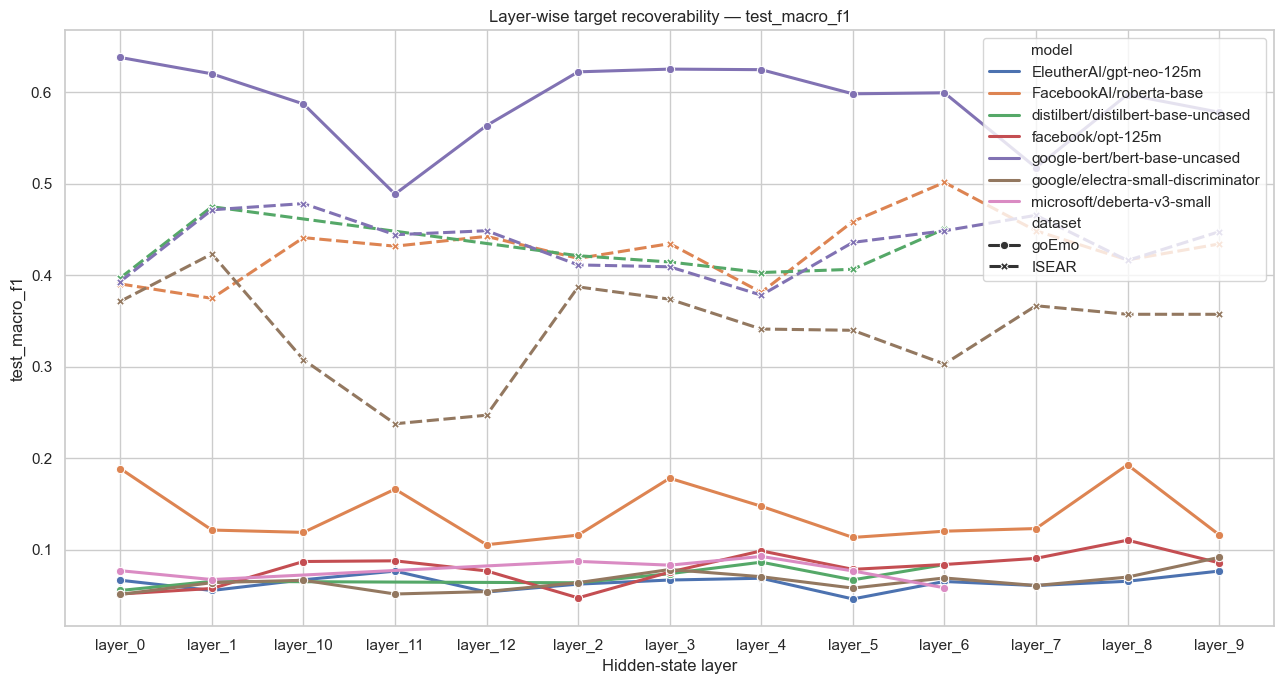

In [6]:
# ============================================================
# 8. Layer-wise trajectory plot
# ============================================================
if not results.empty and PRIMARY_METRIC:
    plot_df = results.copy()

    layer_candidates = ["layer", "layer_idx", "layer_index"]
    layer_col = next((c for c in layer_candidates if c in plot_df.columns), None)
    if layer_col is None:
        raise ValueError("Could not find a layer index column.")

    model_col = next((c for c in ["model", "model_name"] if c in plot_df.columns), None)
    data_col = next((c for c in ["dataset", "dataset_name"] if c in plot_df.columns), None)

    group_cols = [c for c in [model_col, data_col] if c]
    if group_cols:
        plot_df[PRIMARY_METRIC] = pd.to_numeric(plot_df[PRIMARY_METRIC], errors="coerce")
        summary = (
            plot_df.dropna(subset=[PRIMARY_METRIC, layer_col])
            .groupby(group_cols + [layer_col], as_index=False)[PRIMARY_METRIC]
            .mean()
        )

        plt.figure(figsize=(13, 7))
        sns.lineplot(
            data=summary,
            x=layer_col,
            y=PRIMARY_METRIC,
            hue=model_col,
            style=data_col if data_col else None,
            markers=True,
            linewidth=2.2,
        )
        plt.title(f"Layer-wise target recoverability — {PRIMARY_METRIC}")
        plt.xlabel("Hidden-state layer")
        plt.ylabel(PRIMARY_METRIC)
        plt.tight_layout()
        plt.show()

## How to read this curve

The important quantity is not merely the highest point. Look for **shape**:

- **Monotonic rise:** later layers progressively expose more linearly accessible target information.
- **Early peak then decline:** target information is highly accessible at an intermediate depth, then becomes less accessible to the chosen probe.
- **Late rise:** the representation increasingly organises around the target deeper in the network.
- **Flat curve:** the target is similarly recoverable throughout the stack.
- **Large jagged changes:** investigate repeat variance, class support, layer-specific instability, or implementation artefacts before assigning a mechanistic story.

A probing curve is therefore better viewed as a **representational profile** than as a single score.

# Part III — The crucial control: compare the real labels with shuffled labels

The pipeline explicitly enables a shuffled-label control and can run that control on every layer. This is one of the strongest safeguards against mistaking model-independent statistical artefacts for meaningful recoverability.

The cleanest visual is an **observed-minus-shuffled advantage** curve.

Interpretation:

> **Observed performance − shuffled-control performance**

A positive, sustained gap is much more informative than a high raw score by itself.

In [7]:
# ============================================================
# 9. Detect shuffled-control columns and compute an advantage
# ============================================================
control_patterns = [
    "shuffle", "shuffled", "random", "control",
]

control_cols = [
    c for c in results.columns
    if any(p in c.lower() for p in control_patterns)
    and pd.api.types.is_numeric_dtype(results[c])
]

print("Potential shuffled/control metrics:")
for c in control_cols:
    print(" •", c)

# Optional manual override if your exact schema uses a known field.
SHUFFLE_METRIC = next((c for c in control_cols if "macro_f1" in c.lower()), None)
print("Chosen shuffle metric:", SHUFFLE_METRIC)

Potential shuffled/control metrics:
 • control_macro_f1
Chosen shuffle metric: control_macro_f1


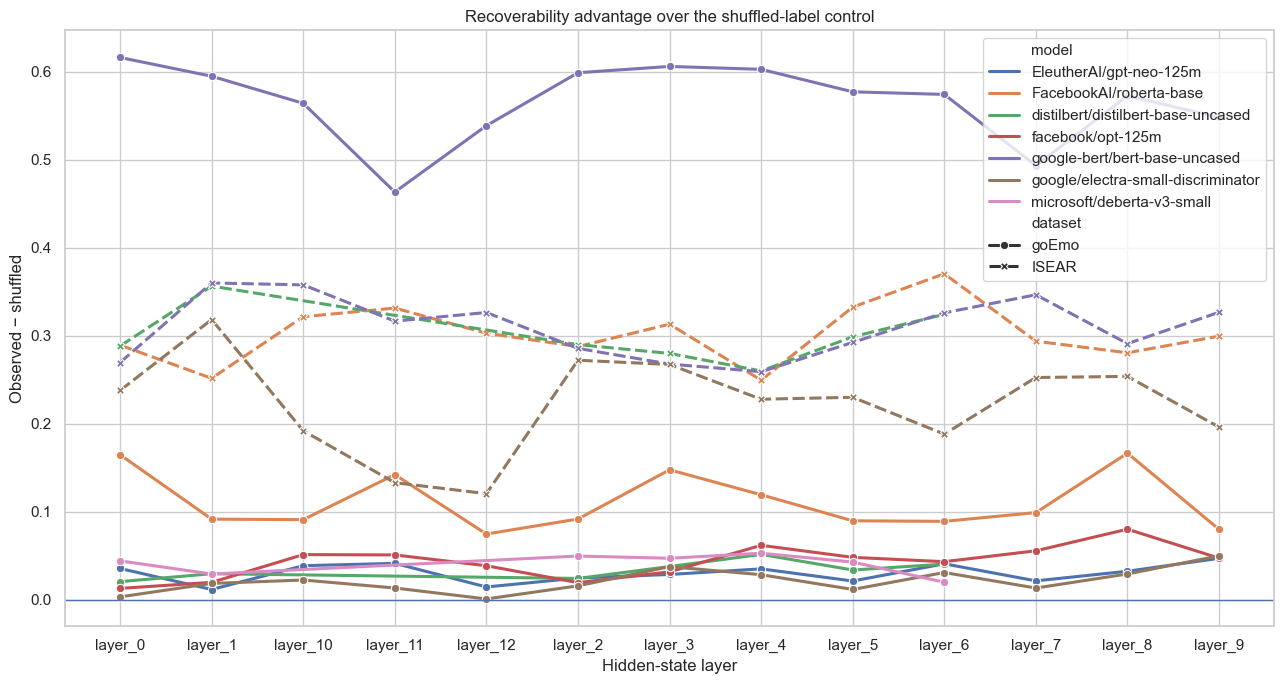

In [8]:
# ============================================================
# 10. Real-vs-shuffle advantage
# ============================================================
if not results.empty and PRIMARY_METRIC and SHUFFLE_METRIC:
    layer_col = next((c for c in ["layer", "layer_idx", "layer_index"] if c in results.columns), None)
    model_col = next((c for c in ["model", "model_name"] if c in results.columns), None)
    data_col = next((c for c in ["dataset", "dataset_name"] if c in results.columns), None)

    tmp = results[[c for c in [layer_col, model_col, data_col, PRIMARY_METRIC, SHUFFLE_METRIC] if c]].copy()
    tmp["advantage"] = (
        pd.to_numeric(tmp[PRIMARY_METRIC], errors="coerce")
        - pd.to_numeric(tmp[SHUFFLE_METRIC], errors="coerce")
    )

    group_cols = [c for c in [model_col, data_col, layer_col] if c]
    tmp = tmp.groupby(group_cols, as_index=False)["advantage"].mean()

    plt.figure(figsize=(13, 7))
    sns.lineplot(
        data=tmp, x=layer_col, y="advantage",
        hue=model_col if model_col else None,
        style=data_col if data_col else None,
        markers=True, linewidth=2.2
    )
    plt.axhline(0, linewidth=1)
    plt.title("Recoverability advantage over the shuffled-label control")
    plt.xlabel("Hidden-state layer")
    plt.ylabel("Observed − shuffled")
    plt.tight_layout()
    plt.show()

## Why this control matters

If the observed probe reaches a strong score **and** the shuffled control reaches a similar score, the raw score is not compelling evidence of target-specific information.

If the observed score separates cleanly from the shuffled baseline across layers, confidence increases that the probe is exploiting structure associated with the real labels.

This still does not prove causal "emotion neurons" or a unique location of learning. It establishes something narrower and defensible: **the target is more recoverable than expected from a label-permuted control under this analysis.**

# Part IV — Probe complexity: linear vs nonlinear access

The code supports multiple probe families (for example logistic and MLP). Their relationship can answer a subtle question:

> Is the target already accessible through a comparatively simple decision boundary, or does a more flexible probe uncover additional information?

A large MLP gain over logistic does **not** automatically mean the model has "learned emotion nonlinearly". It means the target was less linearly accessible under the exact probe settings, while the nonlinear probe could exploit additional structure.

In [9]:
# ============================================================
# 11. Compare probe families
# ============================================================
probe_tokens = ["logistic", "mlp", "linear"]
probe_columns = {}

for token in probe_tokens:
    probe_columns[token] = [
        c for c in results.columns
        if token in c.lower() and c.lower().endswith(("macro_f1", "micro_f1", "accuracy"))
    ]

print("Detected probe-related columns:")
for k, v in probe_columns.items():
    print(k, "→", v[:10])

Detected probe-related columns:
logistic → []
mlp → []
linear → []


probe,linear_logistic,mlp_1_hidden,mlp_2_hidden,mlp_3_hidden
layer,,,,
layer_0,0.260033,0.234309,0.252036,0.228266
layer_1,0.278879,0.264799,0.242815,0.230017
layer_10,0.304503,0.277009,0.242396,0.253010
layer_11,0.294994,0.246207,0.271299,0.179646
layer_12,0.290387,0.252702,0.231308,0.221455
layer_2,0.281429,0.246932,0.226778,0.227027
layer_3,0.284299,0.249496,0.259479,0.229508
layer_4,0.278207,0.263956,0.219088,0.217833
layer_5,0.291047,0.236456,0.237476,0.209133


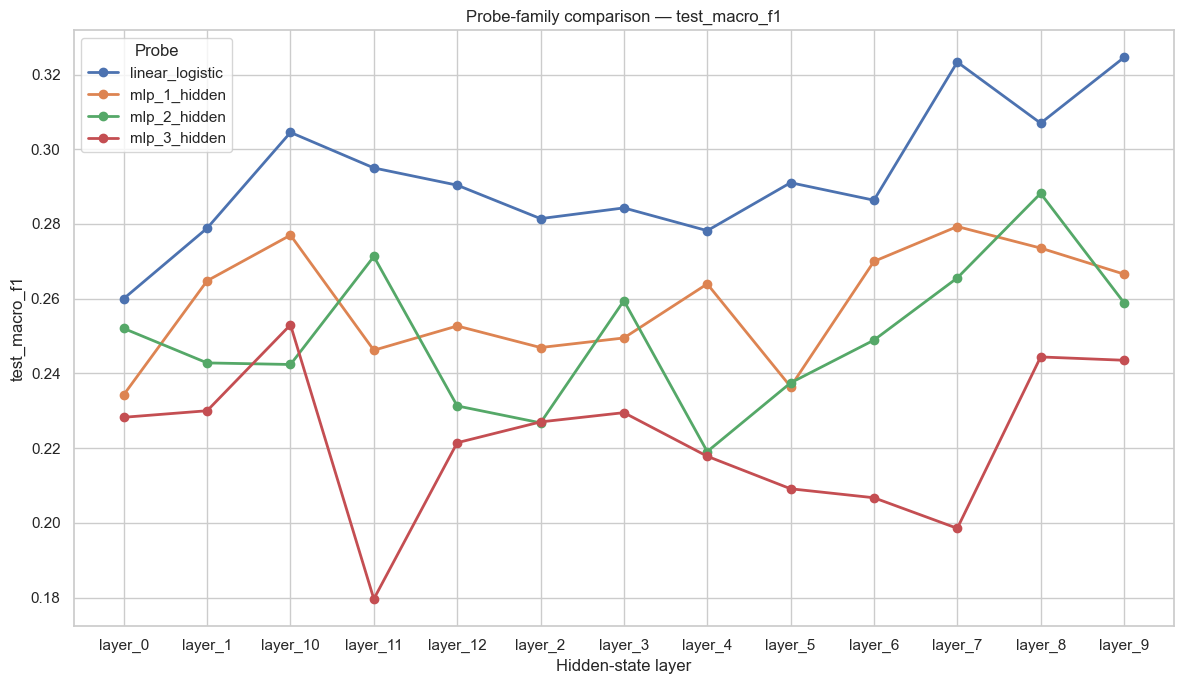

In [10]:
# ============================================================
# 12. Flexible-probe gain, when schema exposes it
# ============================================================
# If your CSV stores probe name in a column, this block becomes the preferred route.
probe_col = next((c for c in ["probe", "probe_name", "probe_type"] if c in results.columns), None)
layer_col = next((c for c in ["layer", "layer_idx", "layer_index"] if c in results.columns), None)

if probe_col and layer_col and PRIMARY_METRIC:
    tmp = results.copy()
    tmp[PRIMARY_METRIC] = pd.to_numeric(tmp[PRIMARY_METRIC], errors="coerce")

    pivot = tmp.pivot_table(
        index=layer_col, columns=probe_col, values=PRIMARY_METRIC, aggfunc="mean"
    )

    display(pivot)

    # Plot all available probe types
    plt.figure(figsize=(12, 7))
    for probe_name in pivot.columns:
        plt.plot(pivot.index, pivot[probe_name], marker="o", linewidth=2, label=str(probe_name))
    plt.title(f"Probe-family comparison — {PRIMARY_METRIC}")
    plt.xlabel("Hidden-state layer")
    plt.ylabel(PRIMARY_METRIC)
    plt.legend(title="Probe")
    plt.tight_layout()
    plt.show()

# Part V — The geometry behind the scores

Scores tell us **how recoverable** the target is. Geometry can show **how the representation is organised**.

The probing pipeline can save PCA/silhouette analyses. Where those outputs are available, use them as a secondary lens:

- PCA: low-dimensional structure of the hidden states.
- Silhouette: how separated the classes are in the chosen representation.
- Probe score: how successfully a classifier can decode the labels.

The strongest story is not "the PCA looks colourful". It is a convergence pattern such as:

**class separation ↑ + probe performance ↑ + shuffled-control gap ↑**

across the same layer region.

In [11]:
# ============================================================
# 13. Automatically discover geometry metrics
# ============================================================
geometry_cols = [
    c for c in results.columns
    if any(t in c.lower() for t in ["silhouette", "pca", "explained_variance"])
]

print("Geometry-related columns found:", geometry_cols)

if geometry_cols:
    display(results[geometry_cols].head())

Geometry-related columns found: ['geometry_silhouette', 'geometry_pca_2d_variance']


,geometry_silhouette,geometry_pca_2d_variance
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


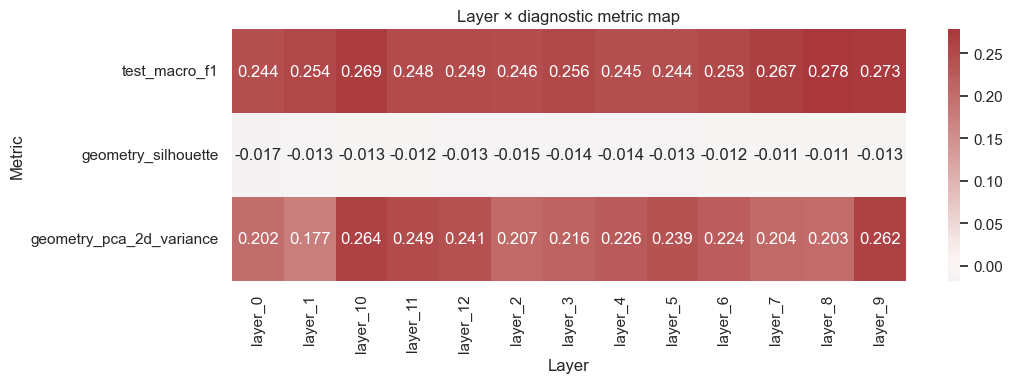

In [12]:
# ============================================================
# 14. Geometry heatmap
# ============================================================
if not results.empty:
    layer_col = next((c for c in ["layer", "layer_idx", "layer_index"] if c in results.columns), None)
    if layer_col and PRIMARY_METRIC:
        candidates = [c for c in [PRIMARY_METRIC] + geometry_cols if c in results.columns]
        if len(candidates) >= 2:
            heat = results.groupby(layer_col)[candidates].mean(numeric_only=True)

            plt.figure(figsize=(11, max(4, 0.55 * len(candidates))))
            sns.heatmap(heat.T, annot=True, fmt=".3f", cmap="vlag", center=0)
            plt.title("Layer × diagnostic metric map")
            plt.xlabel("Layer")
            plt.ylabel("Metric")
            plt.tight_layout()
            plt.show()

# Part VI — Class-level analysis: where the headline score can hide problems

The run log reports that all 28 GoEmotions labels had positive support, but several classes were rare.

That matters because macro-F1 is sensitive to minority-class behaviour, while micro-F1 can be dominated by common labels.

A serious probe report should therefore inspect **per-class performance**, not only the aggregate line.

In [13]:
# ============================================================
# 15. Find per-class metric files
# ============================================================
# The probing code writes metrics.json under:
# models/<probe>/<layer>/<repeat>/metrics.json
metric_paths = sorted(RESULT_ROOT.glob(METRICS_GLOB))
print(f"Found {len(metric_paths)} metrics.json files.")

# Read a small sample to inspect the schema.
samples = []
for p in metric_paths[:10]:
    try:
        obj = json.loads(p.read_text(encoding="utf-8"))
        samples.append((str(p), obj))
    except Exception:
        pass

for path, obj in samples[:3]:
    print("\n", path)
    print("top-level keys:", list(obj)[:20])

Found 736 metrics.json files.

 /Volumes/Amirali/hidden_states/experiments/baseline_v5_001/models/EleutherAI/gpt-neo-125m/datasets/goEmo/analysis/probes/matrix_runs/unified_v4_20260829_135913/models/linear_logistic/layer_0/repeat_0/metrics.json
top-level keys: ['record', 'results']

 /Volumes/Amirali/hidden_states/experiments/baseline_v5_001/models/EleutherAI/gpt-neo-125m/datasets/goEmo/analysis/probes/matrix_runs/unified_v4_20260829_135913/models/linear_logistic/layer_1/repeat_0/metrics.json
top-level keys: ['record', 'results']

 /Volumes/Amirali/hidden_states/experiments/baseline_v5_001/models/EleutherAI/gpt-neo-125m/datasets/goEmo/analysis/probes/matrix_runs/unified_v4_20260829_135913/models/linear_logistic/layer_10/repeat_0/metrics.json
top-level keys: ['record', 'results']


### Suggested per-class visual

Once the metrics JSON contains per-class precision/recall/F1, the most informative figure is usually a **class × layer heatmap**.

That exposes a pattern that the aggregate curve can hide:

- a few classes improving dramatically;
- common classes staying high while rare classes lag;
- an intermediate layer being best overall but another layer being better for minority categories;
- systematic confusion among semantically related emotions.

The following helper looks for conventional `per_class` / `classification_report` style structures.

In [14]:
# ============================================================
# 16. Extract class-level F1 where available
# ============================================================
def find_class_metrics(obj):
    candidates = []
    if isinstance(obj, dict):
        for key, val in obj.items():
            if isinstance(val, dict):
                # Typical nested format: {"class_name": {"f1": ...}}
                for cls, metrics in val.items():
                    if isinstance(metrics, dict):
                        for mname in ["f1", "f1_score", "precision", "recall"]:
                            if mname in metrics and isinstance(metrics[mname], (int, float)):
                                candidates.append((str(cls), mname, float(metrics[mname])))
    return candidates

rows = []
for p in metric_paths:
    try:
        obj = json.loads(p.read_text(encoding="utf-8"))
        found = find_class_metrics(obj)
        for cls, metric, value in found:
            rows.append({"path": str(p), "class": cls, "metric": metric, "value": value})
    except Exception:
        continue

class_metrics = pd.DataFrame(rows)
print("Class-level records:", class_metrics.shape)
display(class_metrics.head(20))

Class-level records: (0, 0)


""


# Part VII — Cross-model comparison as a matrix, not a pile of line charts

When several models are tested, a compact **model × layer heatmap** often reveals the hierarchy much faster than ten separate figures.

For each model, identify:

- the best layer;
- the best score;
- the layer at which the strongest score first appears;
- the persistence of the signal after the peak.

This turns a long experiment log into a comparative representational profile.

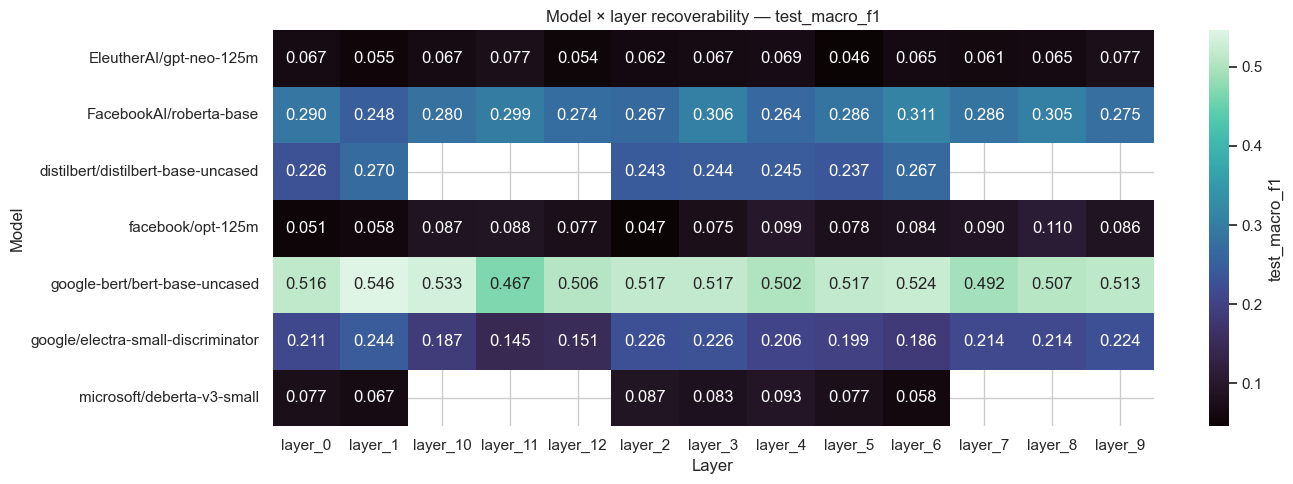

In [15]:
# ============================================================
# 17. Model × layer heatmap
# ============================================================
if not results.empty and PRIMARY_METRIC:
    model_col = next((c for c in ["model", "model_name"] if c in results.columns), None)
    layer_col = next((c for c in ["layer", "layer_idx", "layer_index"] if c in results.columns), None)

    if model_col and layer_col:
        tmp = results[[model_col, layer_col, PRIMARY_METRIC]].copy()
        tmp[PRIMARY_METRIC] = pd.to_numeric(tmp[PRIMARY_METRIC], errors="coerce")
        mat = tmp.pivot_table(index=model_col, columns=layer_col, values=PRIMARY_METRIC, aggfunc="mean")

        plt.figure(figsize=(14, max(5, 0.55 * len(mat))))
        sns.heatmap(mat, annot=True, fmt=".3f", cmap="mako", cbar_kws={"label": PRIMARY_METRIC})
        plt.title(f"Model × layer recoverability — {PRIMARY_METRIC}")
        plt.xlabel("Layer")
        plt.ylabel("Model")
        plt.tight_layout()
        plt.show()

In [16]:
# ============================================================
# 18. Best-layer summary table
# ============================================================
if not results.empty and PRIMARY_METRIC:
    model_col = next((c for c in ["model", "model_name"] if c in results.columns), None)
    data_col = next((c for c in ["dataset", "dataset_name"] if c in results.columns), None)
    layer_col = next((c for c in ["layer", "layer_idx", "layer_index"] if c in results.columns), None)

    if model_col and layer_col:
        tmp = results.copy()
        tmp[PRIMARY_METRIC] = pd.to_numeric(tmp[PRIMARY_METRIC], errors="coerce")
        keys = [c for c in [model_col, data_col] if c]

        summary = []
        for key, g in tmp.dropna(subset=[PRIMARY_METRIC]).groupby(keys):
            idx = g[PRIMARY_METRIC].idxmax()
            r = g.loc[idx]
            summary.append({
                **({keys[0]: key[0]} if len(keys) > 1 else {keys[0]: key}),
                **({keys[1]: key[1]} if len(keys) > 1 else {}),
                "best_layer": r[layer_col],
                "best_score": r[PRIMARY_METRIC],
            })

        best_layer_table = pd.DataFrame(summary).sort_values("best_score", ascending=False)
        display(best_layer_table)

,model,dataset,best_layer,best_score
7,google-bert/bert-base-uncased,goEmo,layer_0,0.678571
1,FacebookAI/roberta-base,ISEAR,layer_6,0.552000
6,google-bert/bert-base-uncased,ISEAR,layer_10,0.529653
3,distilbert/distilbert-base-uncased,ISEAR,layer_1,0.491537
8,google/electra-small-discriminator,ISEAR,layer_1,0.461538
2,FacebookAI/roberta-base,goEmo,layer_6,0.361479
9,google/electra-small-discriminator,goEmo,layer_9,0.145649
5,facebook/opt-125m,goEmo,layer_8,0.143040
10,microsoft/deberta-v3-small,goEmo,layer_4,0.120199
4,distilbert/distilbert-base-uncased,goEmo,layer_5,0.113783


# Part VIII — Stability and uncertainty

The supplied matrix configuration uses `repeats=1` in the shown OPT/goEmo run. That is enough for an initial diagnostic, but it is weaker than repeated estimation.

A visually impressive curve with one split can be misleading if small changes in the train/validation/test partition substantially change the result.

The probing system supports repeated runs. When repeated outputs are present, show:

- mean;
- standard deviation;
- confidence interval or bootstrap interval;
- optionally the distribution of best-layer locations.

Do not manufacture uncertainty when only one repeat exists.

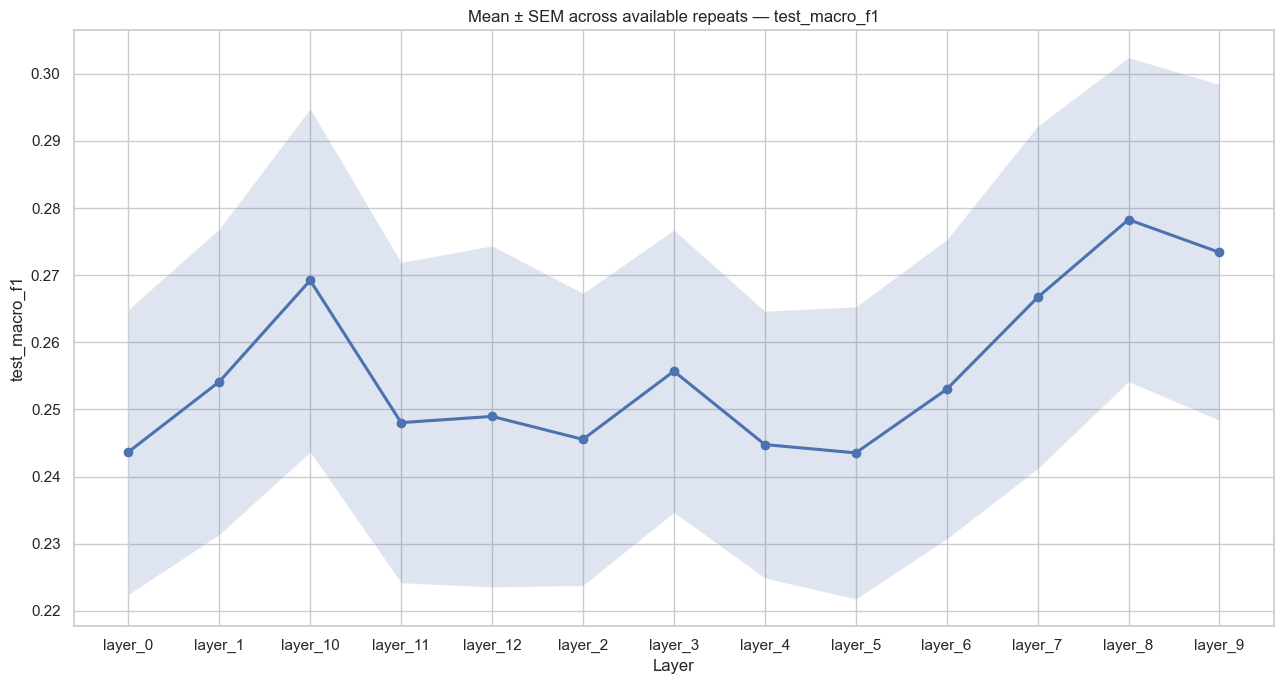

In [17]:
# ============================================================
# 19. Repeated-run uncertainty, when repeats exist
# ============================================================
repeat_col = next((c for c in ["repeat", "repeat_id", "seed"] if c in results.columns), None)
layer_col = next((c for c in ["layer", "layer_idx", "layer_index"] if c in results.columns), None)

if repeat_col and layer_col and PRIMARY_METRIC:
    tmp = results.copy()
    tmp[PRIMARY_METRIC] = pd.to_numeric(tmp[PRIMARY_METRIC], errors="coerce")

    grouped = (
        tmp.groupby([layer_col], as_index=False)[PRIMARY_METRIC]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    grouped["sem"] = grouped["std"] / np.sqrt(grouped["count"].clip(lower=1))

    plt.figure(figsize=(13, 7))
    plt.plot(grouped[layer_col], grouped["mean"], marker="o", linewidth=2.2)
    plt.fill_between(
        grouped[layer_col],
        grouped["mean"] - grouped["sem"],
        grouped["mean"] + grouped["sem"],
        alpha=0.18,
    )
    plt.title(f"Mean ± SEM across available repeats — {PRIMARY_METRIC}")
    plt.xlabel("Layer")
    plt.ylabel(PRIMARY_METRIC)
    plt.tight_layout()
    plt.show()
else:
    print("No repeat identifier detected; do not infer a variance estimate from this run.")

# Part IX — A research-grade "signal strength" view

A useful synthesis is to combine several **non-redundant** indicators:

- absolute held-out probe score;
- improvement over shuffled labels;
- class-balanced performance;
- geometric separation, where available;
- stability across repeats;
- complexity gap between linear and nonlinear probes.

This is not a magic scalar "truth score". Instead, it is a visual dashboard showing whether several independent diagnostics agree.

In [18]:
# ============================================================
# 20. Diagnostic dashboard data
# ============================================================
# Build a compact layer-level diagnostic frame from whatever is present.
if not results.empty:
    layer_col = next((c for c in ["layer", "layer_idx", "layer_index"] if c in results.columns), None)
    diag_cols = [c for c in [
        PRIMARY_METRIC,
        "test_balanced_accuracy",
        "test_micro_f1",
        "test_macro_f1",
        "test_mcc",
        "test_hamming_score",
        "test_macro_jaccard",
    ] if c in results.columns]

    if layer_col and diag_cols:
        dashboard = results.groupby(layer_col)[diag_cols].mean(numeric_only=True)
        display(dashboard.round(4))

,test_macro_f1,test_balanced_accuracy,test_micro_f1,test_macro_f1,test_mcc,test_hamming_score,test_macro_jaccard
layer,,,,,,,
layer_0,0.2437,0.2910,0.2846,0.2437,0.2678,0.8428,0.1394
layer_1,0.2541,0.3076,0.2771,0.2541,0.2852,0.8499,0.1296
layer_10,0.2692,0.3220,0.3365,0.2692,0.3187,0.8554,0.1620
layer_11,0.2480,0.2989,0.3213,0.2480,0.2913,0.8647,0.1491
layer_12,0.2490,0.2925,0.3205,0.2490,0.2912,0.8637,0.1491
layer_2,0.2455,0.2795,0.2812,0.2455,0.2765,0.8765,0.1326
layer_3,0.2557,0.3138,0.3045,0.2557,0.2957,0.8404,0.1436
layer_4,0.2448,0.3077,0.3087,0.2448,0.2904,0.8498,0.1429
layer_5,0.2435,0.2862,0.2683,0.2435,0.2641,0.8648,0.1272


In [19]:
# ============================================================
# 21. Multi-metric radar is avoided intentionally;
#     instead use a normalised diagnostic heatmap.
# ============================================================
if 'dashboard' in globals() and not dashboard.empty:
    norm = dashboard.copy()
    for c in norm.columns:
        vals = norm[c].astype(float)
        if vals.max() > vals.min():
            norm[c] = (vals - vals.min()) / (vals.max() - vals.min())
        else:
            norm[c] = 0.5

    plt.figure(figsize=(12, 6))
    sns.heatmap(norm.T, annot=True, fmt=".2f", cmap="crest", vmin=0, vmax=1)
    plt.title("Normalised diagnostic profile across layers")
    plt.xlabel("Layer")
    plt.ylabel("Diagnostic (0 = low within-run, 1 = high within-run)")
    plt.tight_layout()
    plt.show()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

# Part X — Optional representation geometry: PCA + UMAP

PCA is useful because it is deterministic and easy to reproduce. UMAP can reveal nonlinear neighbourhood structure, but it is also more sensitive to its hyperparameters.

The recommended practice is:

**PCA first → UMAP second as a qualitative companion, never as the primary proof.**

These cells are intentionally optional because they require access to the actual hidden-state arrays rather than only the CSV summary.

In [ ]:
# ============================================================
# 22. Optional PCA/UMAP inspection of raw hidden states
# ============================================================
# Set this only when you want to inspect a concrete extracted artifact.
HIDDEN_STATES_PATH = None  # e.g. Path(".../hidden_states.npy")
TARGET_LABELS_PATH = None  # optional npy/pickle/csv path

print("HIDDEN_STATES_PATH =", HIDDEN_STATES_PATH)
print("This section remains inactive until explicit paths are supplied.")

In [ ]:
# ============================================================
# 23. Optional PCA plot
# ============================================================
if HIDDEN_STATES_PATH is not None:
    from sklearn.decomposition import PCA

    X = np.load(HIDDEN_STATES_PATH, mmap_mode="r")
    # Example: inspect one layer and mean-pool if your array is [N, L, D].
    layer_to_plot = X.shape[1] - 1
    Z = np.asarray(X[:, layer_to_plot, :], dtype=np.float32)

    pca = PCA(n_components=2, random_state=42)
    Z2 = pca.fit_transform(Z)

    plt.figure(figsize=(10, 8))
    plt.scatter(Z2[:, 0], Z2[:, 1], s=8, alpha=0.35)
    plt.title(f"PCA of hidden states — layer {layer_to_plot}")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# 24. Optional UMAP
# ============================================================
if HIDDEN_STATES_PATH is not None:
    try:
        import umap
        print("UMAP available.")
        # Reuse Z from the PCA cell if it exists.
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=30,
            min_dist=0.1,
            metric="cosine",
            random_state=42,
        )
        U = reducer.fit_transform(Z[:10000])

        plt.figure(figsize=(10, 8))
        plt.scatter(U[:, 0], U[:, 1], s=8, alpha=0.35)
        plt.title("UMAP neighbourhood structure (qualitative)")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("Optional dependency missing: pip install umap-learn")

# Part XI — What the supplied run already establishes

Before looking at any future plot, the supplied log supports several firm statements.

### 1. The ISEAR result is currently incomplete

Multiple models fail at row 0 because the analysis expects named emotions but receives the value `1`. That is a target-contract problem. The correct scientific response is to repair the canonical label mapping and rerun the affected entries.

### 2. The successful GoEmotions/OPT run is a 13-layer representation experiment

The hidden states are reported as **54,263 samples × 13 layers × 768 dimensions**, and the task is multi-label with 28 classes.

### 3. The experiment was deliberately capped

Only 500 samples were used and only one repeat was shown in the log. That makes the output appropriate for a **diagnostic probe result**, but not yet the strongest possible stability claim.

### 4. The log reports text verification but not label verification

The probe records `text=verified | labels=unverified` before continuing, while also recording that the label verification basis can inherit confidence from the text sequence. That distinction deserves explicit attention in any final thesis write-up.

# Part XII — A disciplined interpretation template

Use this language when converting the notebook into a thesis result:

> **We measured target recoverability from frozen hidden states layer by layer using held-out probe performance. We compared real-label performance against shuffled-label controls and inspected class-balanced and per-class behaviour where available. A layer with higher recoverability indicates that the target is more accessible to the chosen probe at that representation depth; this is evidence of decodability, not by itself evidence that the representation causally encodes the target or that learning "happens" exclusively at that layer.**

Then add only claims directly supported by your actual curves and uncertainty estimates.

# Part XIII — Final synthesis panel

The final page should answer five questions, in this order:

**A. Is the run valid?**  
Check alignment, label contracts, sample counts, and failures.

**B. Where is the target most recoverable?**  
Report the best layer and the trajectory, not only the global maximum.

**C. Is the signal target-specific?**  
Report the observed-minus-shuffled gap.

**D. Is the result balanced across classes and stable across repeats?**  
Inspect macro metrics, per-class heatmaps, and repeat variance.

**E. Is the pattern consistent across models?**  
Use the model × layer matrix and compare the location and shape of recoverability peaks.

That sequence turns a collection of CSVs into an argument.

In [ ]:
# ============================================================
# 25. FINAL EXECUTIVE SUMMARY TABLE
# ============================================================
if not results.empty and PRIMARY_METRIC:
    model_col = next((c for c in ["model", "model_name"] if c in results.columns), None)
    data_col = next((c for c in ["dataset", "dataset_name"] if c in results.columns), None)
    layer_col = next((c for c in ["layer", "layer_idx", "layer_index"] if c in results.columns), None)

    if model_col and layer_col:
        tmp = results.copy()
        tmp[PRIMARY_METRIC] = pd.to_numeric(tmp[PRIMARY_METRIC], errors="coerce")

        keys = [model_col] + ([data_col] if data_col else [])
        rows = []

        for key, g in tmp.dropna(subset=[PRIMARY_METRIC]).groupby(keys):
            if not isinstance(key, tuple):
                key = (key,)
            best_idx = g[PRIMARY_METRIC].idxmax()
            best = g.loc[best_idx]

            row = {
                model_col: key[0],
                "best_layer": best[layer_col],
                "best_score": float(best[PRIMARY_METRIC]),
                "n_layers": int(g[layer_col].nunique()),
            }
            if data_col:
                row[data_col] = key[1]
            rows.append(row)

        final_summary = pd.DataFrame(rows).sort_values("best_score", ascending=False)
        display(final_summary.style.format({"best_score": "{:.4f}"}))
    else:
        print("Insufficient columns for a model-level summary.")

# Final note — what this notebook does *not* claim

This notebook is deliberately conservative.

A strong probe result means:

**the target is recoverable from the representation.**

It does not automatically mean:

**the target is causally responsible for the representation, that a single neuron stores the emotion, or that the model "learns emotion" at the layer with the highest score.**

The scientifically interesting next step is to combine probing with **controls and interventions**: select candidate directions/features, test counterfactual perturbations, and ask whether manipulating the representation changes the model's behaviour in the expected way.

That is the point where a probing study can move from **where information is accessible** toward **what role that information plays**.